In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    classification_report
)


In [6]:
#load data

data = fetch_california_housing()
print(data.data.shape, data.target.shape)



(20640, 8) (20640,)


In [7]:
print(data.feature_names[0:6])

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


In [8]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [10]:
# data split
# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)


print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (14448, 8)
Validation shape: (3096, 8)
Test shape: (3096, 8)


In [11]:
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [68]:
#scaling

scaler = StandardScaler()
# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("scaling completed")

scaling completed


In [69]:
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully.")

Scaler saved successfully.


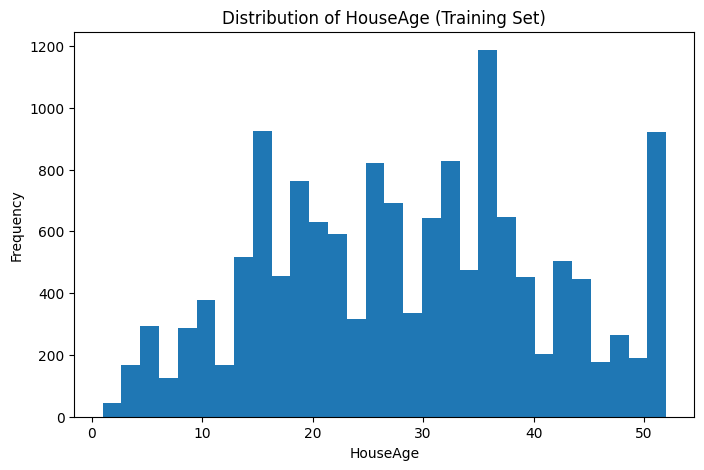

In [70]:
plt.figure(figsize=(8,5))
plt.hist(X_train["HouseAge"], bins=30)
plt.title("Distribution of HouseAge (Training Set)")
plt.xlabel("HouseAge")
plt.ylabel("Frequency")
plt.savefig("HouseAge_histogram.png")
plt.show()

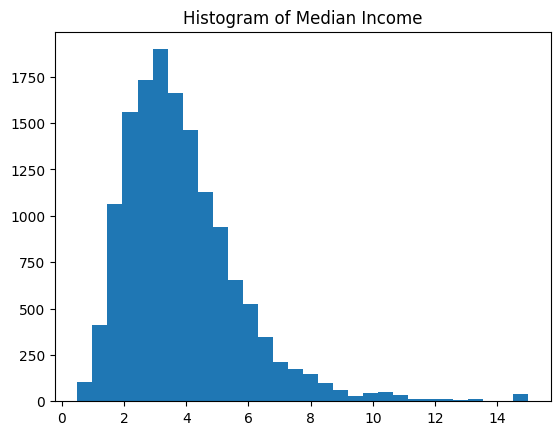

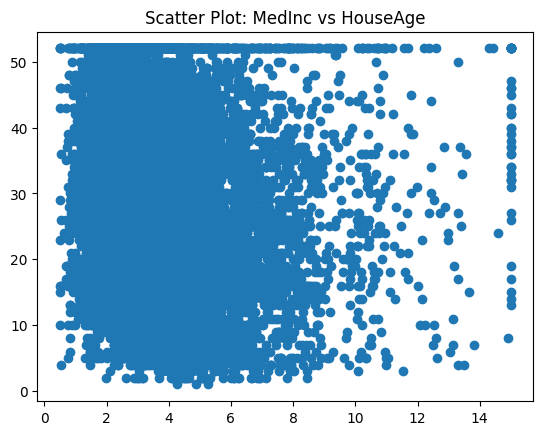

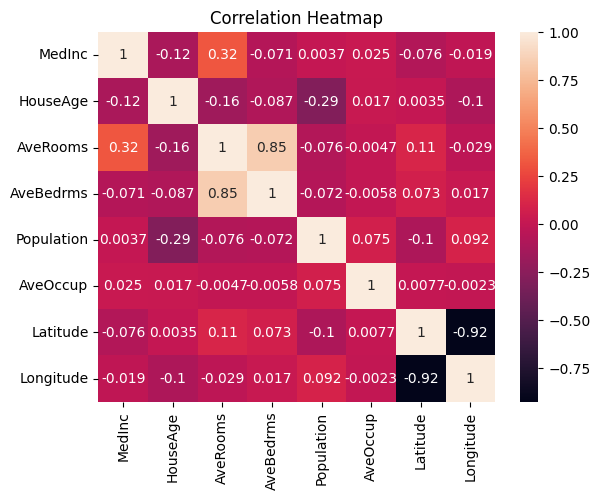

In [71]:

plt.hist(X_train["MedInc"], bins=30)
plt.title("Histogram of Median Income")
plt.savefig("hist_median_inclome.png")
plt.show()

plt.scatter(X_train["MedInc"], X_train["HouseAge"])
plt.title("Scatter Plot: MedInc vs HouseAge")
plt.savefig("scatter_medInc_VS_houseAge.png")
plt.show()

sns.heatmap(X_train.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("heatMap_correlation.png")
plt.show()


In [15]:

# PHASE 2: REGRESSION

# Select only one feature
X_train_simple = X_train[["HouseAge"]]
X_val_simple = X_val[["HouseAge"]]
X_test_simple = X_test[["HouseAge"]]

# Scale the feature
scaler_simple = StandardScaler()
X_train_simple_scaled = scaler_simple.fit_transform(X_train_simple)
X_val_simple_scaled = scaler_simple.transform(X_val_simple)
X_test_simple_scaled = scaler_simple.transform(X_test_simple)

#Train model
simple_reg_model = LinearRegression()
simple_reg_model.fit(X_train_simple_scaled, y_train)

# Validation predictions
y_val_pred_simple = simple_reg_model.predict(X_val_simple_scaled)

mse_val_simple = mean_squared_error(y_val, y_val_pred_simple)
r2_val_simple = r2_score(y_val, y_val_pred_simple)
print("Simple Linear Regression (HouseAge) - Validation MSE:", mse_val_simple)
print("Simple Linear Regression (HouseAge) - Validation R2:", r2_val_simple)


Simple Linear Regression (HouseAge) - Validation MSE: 1.2862560441314417
Simple Linear Regression (HouseAge) - Validation R2: 0.0126743440433843


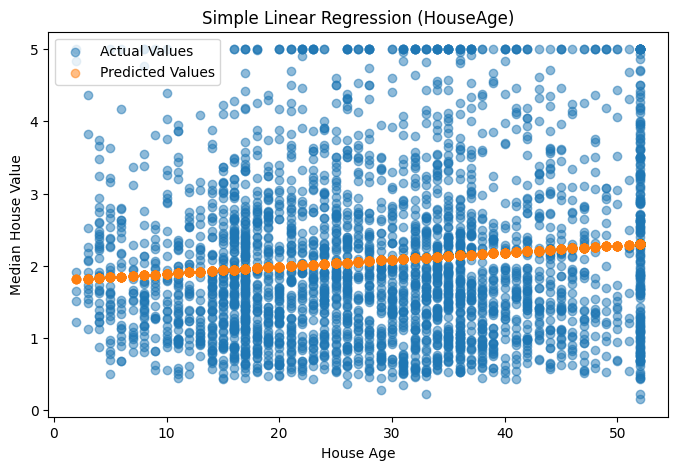

In [72]:
plt.figure(figsize=(8,5))
plt.scatter(X_val_simple, y_val, alpha=0.5, label="Actual Values")
plt.scatter(X_val_simple, y_val_pred_simple, alpha=0.5, label="Predicted Values")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression (HouseAge)")
plt.savefig("simple_linear_regression.png")
plt.legend()
plt.show()

In [17]:
# -------- Multiple Linear Regression (All Features) --------

# Train model
multiple_model = LinearRegression()
multiple_model.fit(X_train_scaled, y_train)

# Validation predictions
y_val_pred_multiple = multiple_model.predict(X_val_scaled)

# Validation metrics
mse_val_multiple = mean_squared_error(y_val, y_val_pred_multiple)
r2_val_multiple = r2_score(y_val, y_val_pred_multiple)

print("Multiple Linear Regression - Validation MSE:", mse_val_multiple)
print("Multiple Linear Regression - Validation R2:", r2_val_multiple)


Multiple Linear Regression - Validation MSE: 0.5408750691093342
Multiple Linear Regression - Validation R2: 0.5848261822866255


In [18]:
# -------- Feature Selection Based on Correlation --------

train_df = X_train.copy()
train_df["MedHouseVal"] = y_train

correlations = train_df.corr()["MedHouseVal"].sort_values(ascending=False)
print(correlations)

MedHouseVal    1.000000
MedInc         0.688229
AveRooms       0.152106
HouseAge       0.106549
AveOccup      -0.020960
Population    -0.024316
AveBedrms     -0.048455
Longitude     -0.049347
Latitude      -0.141528
Name: MedHouseVal, dtype: float64


In [19]:
selected_features = ["MedInc", "AveRooms", "Latitude", "HouseAge"]

X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

# Scale selected features
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_val_selected_scaled = scaler_selected.transform(X_val_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)


In [20]:
# -------- Tuned Regression Model --------

tuned_model = LinearRegression()
tuned_model.fit(X_train_selected_scaled, y_train)

# Validation predictions
y_val_pred_tuned = tuned_model.predict(X_val_selected_scaled)

# Validation metrics
mse_val_tuned = mean_squared_error(y_val, y_val_pred_tuned)
r2_val_tuned = r2_score(y_val, y_val_pred_tuned)

print("Tuned Model - Validation MSE:", mse_val_tuned)
print("Tuned Model - Validation R2:", r2_val_tuned)


Tuned Model - Validation MSE: 0.6559731528047935
Tuned Model - Validation R2: 0.4964772944408118


In [21]:
print("Validation Results Comparison:")
print("--------------------------------")
print("Simple Regression R2:", r2_val_simple)
print("Multiple Regression R2:", r2_val_multiple)
print("Tuned Regression R2:", r2_val_tuned)


Validation Results Comparison:
--------------------------------
Simple Regression R2: 0.0126743440433843
Multiple Regression R2: 0.5848261822866255
Tuned Regression R2: 0.4964772944408118


In [22]:
# -------- Final Test Evaluation --------

y_test_pred = multiple_model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Final Test MSE:", mse_test)
print("Final Test R2:", r2_test)


Final Test MSE: 0.5202604958440162
Final Test R2: 0.6065519204153755


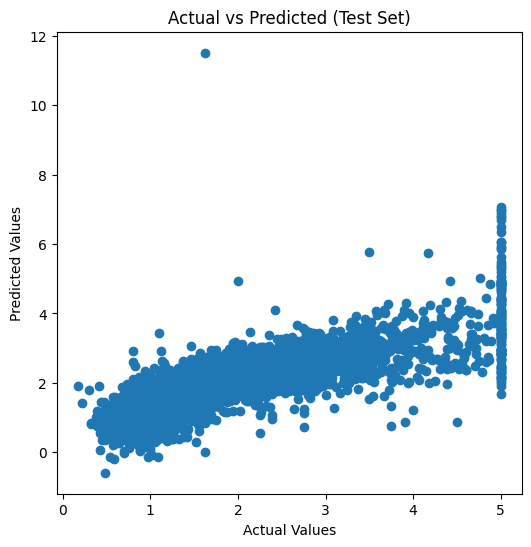

In [73]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Set)")
plt.savefig("static/multiple_linear_regression.png")
plt.show()


In [24]:
import joblib

joblib.dump(multiple_model, "regression_model.pkl")
print("Regression model saved successfully.")

Regression model saved successfully.


In [25]:
# PHASE 3: CLASSIFICATION 

# Calculate percentiles from training target
low_threshold = y_train.quantile(0.33)
high_threshold = y_train.quantile(0.66)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)



Low threshold: 1.405
High threshold: 2.273


In [26]:
def categorize_price(value):
    if value <= low_threshold:
        return 0   # Low
    elif value <= high_threshold:
        return 1   # Medium
    else:
        return 2   # High

# Create classification targets
y_train_clf = y_train.apply(categorize_price)
y_val_clf = y_val.apply(categorize_price)
y_test_clf = y_test.apply(categorize_price)

print("Class distribution (Training Set):")
print(y_train_clf.value_counts())

Class distribution (Training Set):
MedHouseVal
2    4910
0    4771
1    4767
Name: count, dtype: int64


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Create model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train
log_model.fit(X_train_scaled, y_train_clf)

# Validation accuracy
val_pred_log = log_model.predict(X_val_scaled)
print("Logistic Validation Accuracy:",
      accuracy_score(y_val_clf, val_pred_log))

# Final Test evaluation
test_pred_log = log_model.predict(X_test_scaled)
log_test_accuracy = accuracy_score(y_test_clf, test_pred_log)

print("Logistic Test Accuracy:", log_test_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test_clf, test_pred_log))

# Save model
joblib.dump(log_model, "logistic_model.pkl")
print("Logistic model saved.")


Logistic Validation Accuracy: 0.7131782945736435
Logistic Test Accuracy: 0.7206072351421189

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      1020
           1       0.59      0.61      0.60      1009
           2       0.79      0.80      0.80      1067

    accuracy                           0.72      3096
   macro avg       0.72      0.72      0.72      3096
weighted avg       0.72      0.72      0.72      3096

Logistic model saved.


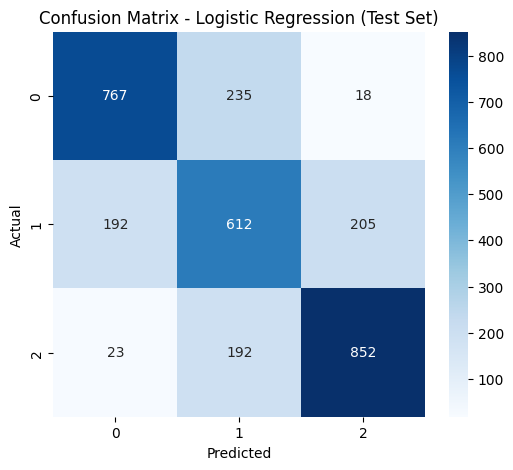

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions (if not already done)
y_test_pred_log = log_model.predict(X_test_scaled)

# Confusion matrix
cm_log = confusion_matrix(y_test_clf, y_test_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Test Set)")
plt.savefig("confusion_matrix_logistic.png")
plt.show()


In [36]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_scaled, y_train_clf)

# Validation accuracy
val_pred_tree = tree_model.predict(X_val_scaled)
print("Decision Tree Validation Accuracy:",
      accuracy_score(y_val_clf, val_pred_tree))

# Final Test evaluation
test_pred_tree = tree_model.predict(X_test_scaled)
tree_test_accuracy = accuracy_score(y_test_clf, test_pred_tree)

print("Decision Tree Test Accuracy:", tree_test_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test_clf, test_pred_tree))

# Save model
joblib.dump(tree_model, "decision_tree_model.pkl")
print("Decision Tree model saved.")


Decision Tree Validation Accuracy: 0.7235142118863049
Decision Tree Test Accuracy: 0.7425710594315246

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1020
           1       0.64      0.64      0.64      1009
           2       0.78      0.79      0.79      1067

    accuracy                           0.74      3096
   macro avg       0.74      0.74      0.74      3096
weighted avg       0.74      0.74      0.74      3096

Decision Tree model saved.


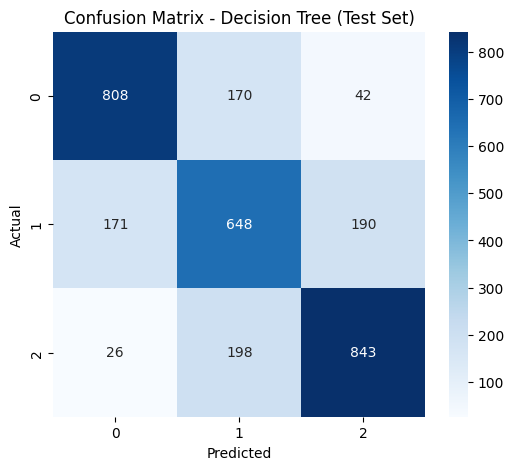

In [37]:
# Generate predictions (if not already done)
y_test_pred_dt = tree_model.predict(X_test_scaled)

# Confusion matrix
cm_dt = confusion_matrix(y_test_clf, y_test_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Test Set)")
plt.savefig("confusion_matrix_decision_tree.png")
plt.show()


In [30]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train_clf)

y_val_pred_rf = rf_model.predict(X_val_scaled)

print("Random Forest - Validation Accuracy:",
      accuracy_score(y_val_clf, y_val_pred_rf))

Random Forest - Validation Accuracy: 0.8000645994832042


In [31]:
# Random Forest Test Prediction
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Store accuracy in variable
rf_test_accuracy = accuracy_score(y_test_clf, y_test_pred_rf)

print("Random Forest Test Accuracy:", rf_test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_clf, y_test_pred_rf))

Random Forest Test Accuracy: 0.8200904392764858

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1020
           1       0.74      0.74      0.74      1009
           2       0.86      0.85      0.86      1067

    accuracy                           0.82      3096
   macro avg       0.82      0.82      0.82      3096
weighted avg       0.82      0.82      0.82      3096



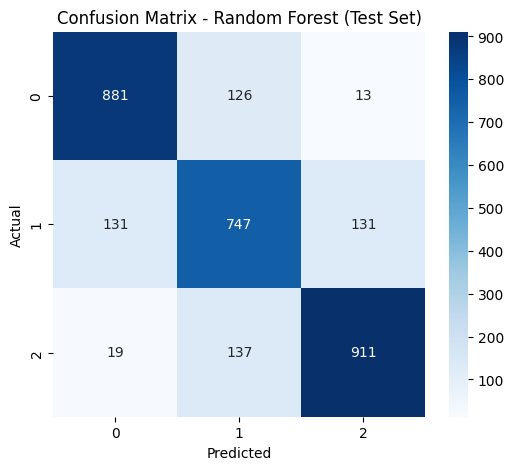

In [33]:
import seaborn as sns

cm = confusion_matrix(y_test_clf, y_test_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Test Set)")
plt.savefig("confusion_matrix_rf.png")
plt.show()

In [34]:
import joblib

joblib.dump(rf_model, "classification_model.pkl")
print("Classification model saved successfully.")

Classification model saved successfully.


In [38]:
#PHASE 4: SVM

# Initial SVM with default settings (RBF kernel, C=1)
svm_initial = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

svm_initial.fit(X_train_scaled, y_train_clf)

print("Initial SVM trained on training set.")


Initial SVM trained on training set.


In [39]:
# Try Linear kernel
svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_scaled, y_train_clf)

y_val_pred_linear = svm_linear.predict(X_val_scaled)
val_acc_linear = accuracy_score(y_val_clf, y_val_pred_linear)

print("Validation Accuracy (Linear Kernel):", val_acc_linear)

Validation Accuracy (Linear Kernel): 0.7154392764857881


In [40]:
c_values = [0.1, 1, 10]

best_val_accuracy = 0
best_c = None

for c in c_values:
    svm_rbf = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm_rbf.fit(X_train_scaled, y_train_clf)
    
    y_val_pred = svm_rbf.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val_clf, y_val_pred)
    
    print(f"Validation Accuracy (RBF, C={c}):", val_accuracy)
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_c = c

print("\nBest C selected for RBF:", best_c)


Validation Accuracy (RBF, C=0.1): 0.7031653746770026
Validation Accuracy (RBF, C=1): 0.7406330749354005
Validation Accuracy (RBF, C=10): 0.7619509043927648

Best C selected for RBF: 10


In [41]:
print("Linear Kernel Validation Accuracy:", val_acc_linear)
print("Best RBF Validation Accuracy:", best_val_accuracy)

Linear Kernel Validation Accuracy: 0.7154392764857881
Best RBF Validation Accuracy: 0.7619509043927648


In [42]:
svm_best = SVC(kernel='rbf', C=best_c, gamma='scale', random_state=42)
svm_best.fit(X_train_scaled, y_train_clf)

print("Final SVM model trained using validation-selected parameters.")


Final SVM model trained using validation-selected parameters.


In [43]:
y_test_pred_svm = svm_best.predict(X_test_scaled)

svm_test_accuracy = accuracy_score(y_test_clf, y_test_pred_svm)

print("SVM Final Test Accuracy:", svm_test_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_clf, y_test_pred_svm))

SVM Final Test Accuracy: 0.7761627906976745

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1020
           1       0.66      0.70      0.68      1009
           2       0.83      0.82      0.83      1067

    accuracy                           0.78      3096
   macro avg       0.78      0.78      0.78      3096
weighted avg       0.78      0.78      0.78      3096



In [ ]:
print("Random Forest Test Accuracy:", rf_test_accuracy)
print("SVM Test Accuracy:", svm_test_accuracy)

Random Forest Test Accuracy: 0.8200904392764858
SVM Test Accuracy: 0.7761627906976745


In [45]:
import joblib

joblib.dump(svm_best, "svm_model.pkl")
print("SVM model saved successfully.")

SVM model saved successfully.


In [49]:
#PHASE 5:NEURAL NETWORK

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings("ignore")

In [50]:

mlp = MLPClassifier(hidden_layer_sizes=(64,),
                    activation='relu',
                    solver='adam',
                    max_iter=1,        # Important for manual epoch control
                    warm_start=True,   # Allows training in loops
                    random_state=42)

In [51]:
epochs = 50

train_acc_list = []
val_acc_list = []

train_loss_list = []
val_loss_list = []

mlp = MLPClassifier(hidden_layer_sizes=(64,),
                    activation='relu',
                    solver='adam',
                    max_iter=1,
                    warm_start=True,
                    random_state=42)

for epoch in range(epochs):
    
    mlp.fit(X_train_scaled, y_train_clf)
    
    # Predictions
    train_pred = mlp.predict(X_train_scaled)
    val_pred = mlp.predict(X_val_scaled)
    
    # Accuracy
    train_acc_list.append(accuracy_score(y_train_clf, train_pred))
    val_acc_list.append(accuracy_score(y_val_clf, val_pred))
    
    # Probabilities (needed for loss)
    train_probs = mlp.predict_proba(X_train_scaled)
    val_probs = mlp.predict_proba(X_val_scaled)
    
    # Log Loss
    train_loss_list.append(log_loss(y_train_clf, train_probs))
    val_loss_list.append(log_loss(y_val_clf, val_probs))

print("Training completed.")

Training completed.


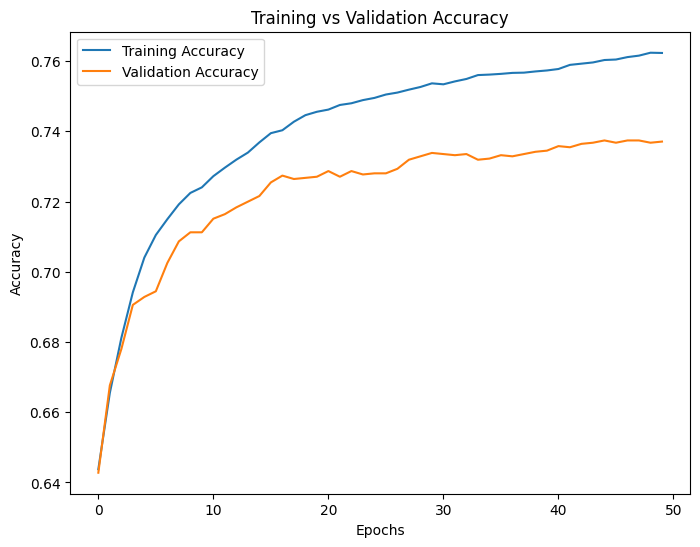

In [52]:
plt.figure(figsize=(8,6))
plt.plot(train_acc_list, label="Training Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.savefig("training_vs_validation_accuracy_NN.png")
plt.legend()
plt.show()


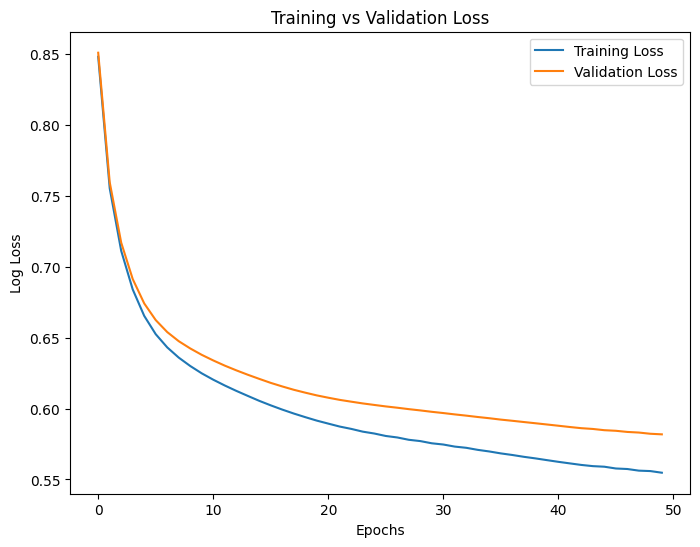

In [53]:
plt.figure(figsize=(8,6))
plt.plot(train_loss_list, label="Training Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss")
plt.savefig("training_vs_validation_loss_NN.png")
plt.legend()
plt.show()

In [54]:
y_test_pred_nn = mlp.predict(X_test_scaled)

nn_test_accuracy = accuracy_score(y_test_clf, y_test_pred_nn)

print("Neural Network Final Test Accuracy:", nn_test_accuracy)


Neural Network Final Test Accuracy: 0.7616279069767442


In [55]:
import joblib

joblib.dump(mlp, "neural_network_model.pkl")
print("Neural Network model saved.")


Neural Network model saved.


In [56]:
#CLUSTERING

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

In [57]:
# Remove target column
X_cluster = df.drop(columns=["MedHouseVal"])

print("Clustering features shape:", X_cluster.shape)

Clustering features shape: (20640, 8)


In [58]:
scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Scaling completed.")

Scaling completed.


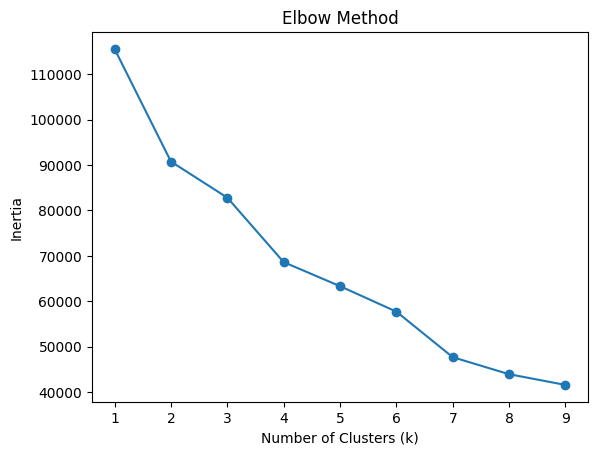

In [61]:
#CLUSTERING + PCA
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.savefig("Elbow_Method.png")
plt.show()



In [62]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

kmeans_final.fit(X_cluster_scaled)

df["Cluster"] = kmeans_final.labels_

print("Final clustering completed.")


Final clustering completed.


In [63]:
cluster_summary = df.groupby("Cluster").mean()

print("Cluster Summary (Mean Values):")
display(cluster_summary)

Cluster Summary (Mean Values):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,3.274461,31.192000,4.757117,1.061849,1368.040737,3.067821,33.965549,-118.037338,1.920485
1,3.640480,29.539157,5.397015,1.077180,1236.521197,2.781592,37.982825,-121.758710,1.923918
2,6.425023,17.941455,7.677622,1.262635,2133.511675,3.880439,34.476981,-118.432809,2.945233


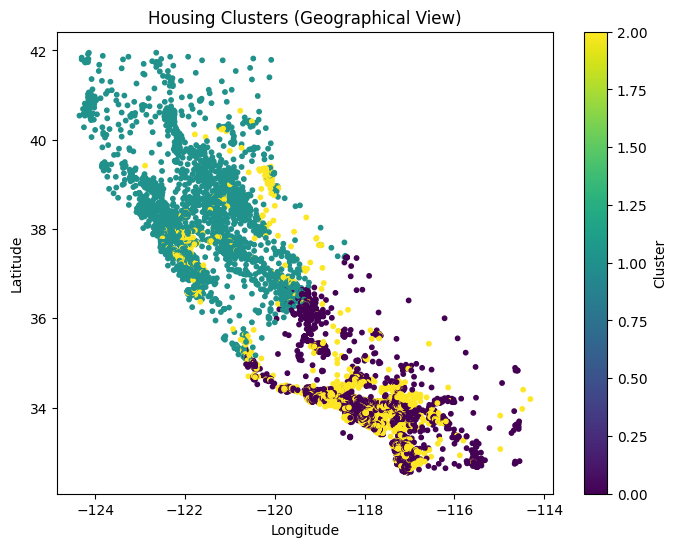

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(df["Longitude"],
            df["Latitude"],
            c=df["Cluster"],
            cmap="viridis",
            s=10)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Housing Clusters (Geographical View)")
plt.colorbar(label="Cluster")
plt.savefig("Geographical_cluster.png")
plt.show()


In [65]:
pca = PCA(n_components=3)

X_pca_3d = pca.fit_transform(X_cluster_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Captured:",
      sum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.25336868 0.23516245 0.15888635]
Total Variance Captured: 0.6474174722211654


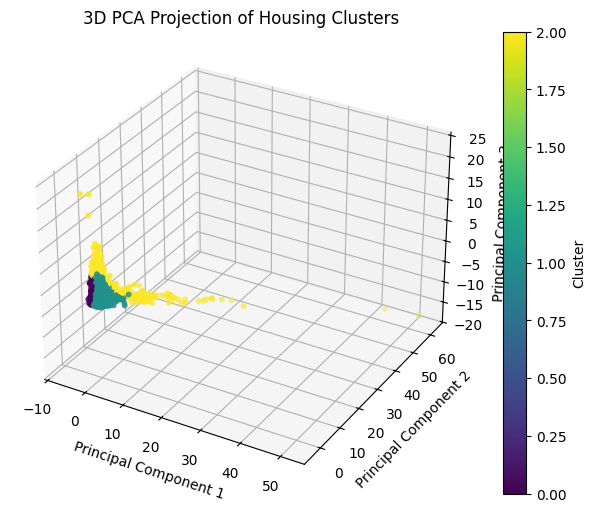

In [66]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0],
                     X_pca_3d[:, 1],
                     X_pca_3d[:, 2],
                     c=df["Cluster"],
                     cmap="viridis",
                     s=10)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Projection of Housing Clusters")

fig.colorbar(scatter, label="Cluster")
plt.savefig("cluster+pca_3d.png")
plt.show()


In [67]:
joblib.dump(kmeans_final, "kmeans_model.pkl")
joblib.dump(scaler_cluster, "cluster_scaler.pkl")

print("Clustering model and scaler saved successfully.")

Clustering model and scaler saved successfully.
